In [1]:
# import packages
from qutip import *
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
#from sklearn import datasets
from scipy.special import hermite
from scipy.integrate import quad
from scipy.linalg import expm, sqrtm
from math import factorial, pi, sqrt
from scipy import special
import ast
from scipy.special import eval_genlaguerre, factorial

In [2]:
# format latex in figures
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)
plt.rcParams.update({'font.size': 16})

## Generalized model with broken Z2 sym ##

In [3]:
from scipy.optimize import brentq

def find_roots(f, a, b, num_points=300000):
    x_vals = np.linspace(a, b, num_points)
    y_vals = f(x_vals)
    roots = []
    
    for i in range(len(x_vals) - 1):
        if y_vals[i] * y_vals[i + 1] < 0:  # Sign change detected
            try:
                root = brentq(f, x_vals[i], x_vals[i + 1])
                roots.append(root)
            except ValueError:
                pass  # Skip cases where brentq fails
    
    return np.array(roots)

def f(n,x,lam,omega,delta,E,sign):
    return 2*lam/omega + (n*omega-x+sign*E+delta**2/(x-n*omega+sign*E+1e-10))/(2*lam)

def K(n,x,lam,omega,delta,E,sign):
    if n == 0:
        return 1
    elif n == 1:
        return f(0,x,lam,omega,delta,E,sign)
    else:
        return ( f(n-1,x,lam,omega,delta,E,sign)*K(n-1,x,lam,omega,delta,E,sign)-K(n-2,x,lam,omega,delta,E,sign) )/n
    
def R_bar(x,order,lam,omega,delta,E,sign):
    result = 0
    for n in range(order):
        result += ( K(n,x,lam,omega,delta,E,sign) / ( x - n*omega + sign*E ) ) * (lam/omega)**n
    return result

def R(x,order,lam,omega,delta,E,sign):
    result = 0
    for n in range(order):
        result += K(n,x,lam,omega,delta,E,sign) * (lam/omega)**n
    return result
    
def G(x,order,lam,omega,delta,E):
    return delta**2 * R_bar(x,order,lam,omega,delta,E,1)*R_bar(x,order,lam,omega,delta,E,-1) - R(x,order,lam,omega,delta,E,1)*R(x,order,lam,omega,delta,E,-1)

def E_rabi(order,lam,omega,delta,level_num,E):

    temp = find_roots(lambda x : G(x,order=order,lam=lam,omega=omega,delta=delta,E=E),
                        -1,100)
    result = []
    for i in range(np.shape(temp)[0]):
        if np.isclose(temp[i]%omega,0) or np.isclose(temp[i]%omega,omega):
            pass
        else:
            result.append(temp[i])
    
    return np.sort(np.array(result - (lam**2/omega)*np.ones(np.shape(result)[0]))[:level_num])

## Define params ##

In [4]:
delta = 1
epsilon = 0
Om = 2*delta
lam_range = np.linspace(0.01,5,100)
beta = 1

In [5]:
# level_num =  6
# order = 6 # need 6 to converge
# spectrum_exact = np.zeros([np.shape(lam_range)[0],level_num])

# for iL in range(np.shape(lam_range)[0]):

#     temp = E_rabi(order,lam_range[iL],Om,delta,level_num,epsilon)
#     spectrum_exact[iL,:] = temp

# spectrum_exact[iL,:] = np.sort(spectrum_exact[iL,:])

# # plot exact eigenenergies
# fig, axes = plt.subplots(1,1,figsize=(7,4))
# for n in range(level_num):
#     axes.plot(lam_range,
#                 spectrum_exact[:,n],
#                 linestyle='solid',
#                 linewidth=1)

# np.save('data//spectrum_exact_E{}.npy'.format(epsilon), spectrum_exact)

## Define Rabi model and its CDH ##

In [6]:
def ket(n,M):
    tmp = np.zeros(M)
    tmp[n] = 1
    return Qobj(tmp)

def MM(s, r, M):
    return ket(s,M)*ket(r,M).dag() * (1j)**(s-r)

def H_RC_M(M):
    def H_RC(lam):
        if M == 1:
            H = delta*sigmaz() + epsilon*sigmax()
        else:
            H = ( delta*tensor(qeye(M),sigmaz()) + epsilon*tensor(qeye(M),sigmax()) 
                + lam*tensor(create(M)+destroy(M),sigmax())
                + Om * tensor(Qobj(create(M).full() @ destroy(M).full()),qeye(2)) )
                #+ Om * tensor(create(M)*destroy(M),qeye(2)) )
        return H
    return H_RC

def H_EFF_M(N): 
    def H_EFF(lam):
        M = 100

        H = ( delta * tensor(qeye(M), sigmaz()) 
            + epsilon * tensor(qeye(M), sigmax()) 
            + lam * tensor(create(M) + destroy(M), sigmax()) 
            + Om * tensor(Qobj(create(M).full() @ destroy(M).full()), qeye(2)) )
        
        UP = (lam / Om * tensor(create(M) - destroy(M), sigmax())).expm()
        H_transformed = UP * H * UP.dag()

        # Convert to dense matrix and slice top-left 2N x 2N block
        H_matrix = H_transformed.full()
        block = H_matrix[:2*N, :2*N]

        if N == 1:
            return Qobj(block, dims=[[2], [2]])
        else:
            return Qobj(block, dims=[[2, N], [2, N]])
        
    return H_EFF

def H_EFF_X_1(lam):
    eps = lam/Om
    return delta*np.exp(-2*eps**2)*sigmaz() + epsilon*sigmax() - lam**2/Om*qeye(2)

def H_EFF_X_2(lam):
    eps = lam/Om
    H = ( delta*np.exp(-2*eps**2)*( tensor(MM(0,1,2)+MM(1,0,2),(-2*eps) * sigmay() ) 
                                  + tensor(MM(0,0,2),sigmaz()) 
                                  + tensor(MM(1,1,2),(1-4*lam**2/Om**2)*sigmaz()) )
                                  + tensor(qeye(2),epsilon*sigmax()) 
                                  + tensor(MM(1,1,2),Om*qeye(2))
                                  + tensor(qeye(2),-lam**2/Om*qeye(2)) )
    return H

def H_EFF_X_3(lam):
    H = ( delta*np.exp(-2*lam**2/Om**2)*( tensor(MM(0,0,3),sigmaz()) 
                                        + tensor(MM(1,1,3),(1-4*lam**2/Om**2)*sigmaz()+np.exp(2*lam**2/Om**2)*Om*qeye(2)) 
                                        + tensor(MM(2,2,3),(1-8*lam**2/Om**2+8*lam**4/Om**4)*sigmaz()+2*np.exp(2*lam**2/Om**2)*Om*qeye(2))
                                        + tensor(MM(0,1,3)+MM(1,0,3),-2*lam/Om*sigmay())
                                        + tensor(MM(0,2,3)+MM(2,0,3),-2*np.sqrt(2)*lam**2/Om**2*sigmaz())
                                        + tensor(MM(1,2,3)+MM(2,1,3),-2*np.sqrt(2)*lam/Om*(1-2*lam**2/Om**2)*sigmay()) )
                                        + tensor(qeye(3),epsilon*sigmax()) - lam**2/Om*tensor(qeye(3),qeye(2)) )
    return H

def H_EFF_X_4(lam):
    eps = lam/Om
    H = ( delta*np.exp(-2*eps**2)*(   tensor(MM(0,0,4)              ,sigmaz()) 
                                    + tensor(MM(1,1,4)              ,(1-4*eps**2)*sigmaz()+np.exp(2*eps**2)*Om*qeye(2)) 
                                    + tensor(MM(2,2,4)              ,(1-8*eps**2+8*eps**4)*sigmaz()+2*np.exp(2*eps**2)*Om*qeye(2))
                                    + tensor(MM(0,1,4)+MM(1,0,4)    ,-2*eps*sigmay())
                                    + tensor(MM(0,2,4)+MM(2,0,4)    ,-2*np.sqrt(2)*eps**2*sigmaz())
                                    + tensor(MM(1,2,4)+MM(2,1,4)    ,-2*np.sqrt(2)*eps*(1-2*eps**2)*sigmay()) 
                                    + tensor(MM(3,0,4)+MM(0,3,4)    ,(4*np.sqrt(2/3)*eps**3)*sigmay() )
                                    + tensor(MM(3,1,4)+MM(1,3,4)    ,(np.sqrt(8/3)*eps**2*(-3+4*eps**2))*sigmaz() )
                                    + tensor(MM(3,2,4)+MM(2,3,4)    ,-((2*eps*(3-12*eps**2+8*eps**4))/np.sqrt(3))*sigmay() )
                                    + tensor(MM(3,3,4)              ,( (3-36*eps**2+72*eps**4-32*eps**6)/3 )*sigmaz()+np.exp(2*eps**2)*3*Om*qeye(2)) )
                                    + tensor(qeye(4),epsilon*sigmax()) 
                                    - lam**2/Om*tensor(qeye(4),qeye(2)) )
    return H

def H_EFF_XpZ_1(lam):
    eps = lam/Om
    return delta*( (np.exp(-eps**2)*np.sinh(eps**2))*sigmax() + (np.exp(-eps**2)*np.cosh(eps**2))*sigmaz() ) - lam**2/Om*qeye(2)

def H_EFF_XpZ_3(lam):
    eps = lam/Om
    H = ( delta*( tensor(MM(0,0,3), (np.exp(-eps**2)*np.sinh(eps**2))*sigmax() + (np.exp(-eps**2)*np.cosh(eps**2))*sigmaz() )
                + tensor(MM(1,1,3), (0.5*(1+np.exp(-2*eps**2)*(-1+4*eps**2)))*sigmax() + (0.5*(1+np.exp(-2*eps**2)*(1-4*eps**2)))*sigmaz() + Om*qeye(2) ) 
                + tensor(MM(2,2,3), (0.5+np.exp(-2*eps**2)*(-0.5+4*eps**2-4*eps**4))*sigmax() + (0.5*(1+np.exp(-2*eps**2)*(1-8*eps**2+8*eps**4)))*sigmaz() + 2*Om*qeye(2) )
                + tensor(MM(0,1,3)+MM(1,0,3), (-np.sqrt(2)*np.exp(-2*eps**2)*eps)*sigmay() ) 
                + tensor(MM(0,2,3)+MM(2,0,3), (np.sqrt(2)*eps**2*np.exp(-2*eps**2))*sigmax() + (-np.sqrt(2)*eps**2*np.exp(-eps**2))*sigmaz() ) 
                + tensor(MM(1,2,3)+MM(2,1,3), (2*np.exp(-2*eps**2)*eps*(-1+2*eps**2))*sigmay() ) ) 
                - lam**2/Om*tensor(qeye(3),qeye(2)))
    return H

## data for the ERROR plot ##

In [7]:
## scpetrum exact brute force ##

H = H_RC_M(100)
spectrum_exact = np.zeros([np.shape(lam_range)[0],6])
for il,lam in enumerate(lam_range):
    spectrum_exact[il,:] = np.real(H(lam).eigenenergies())[:6]

In [8]:
# Ms = [1,2,3,4,5,6,7,8,9,10] # up to 10 for main
# LVLs = [0,1,2]
# points = np.zeros([np.shape(Ms)[0],np.shape(LVLs)[0]])
# for iM,M in enumerate(Ms):
#     for iLVL,LVL in enumerate(LVLs):

#         spectrum = np.zeros([np.shape(lam_range)[0],2*np.max(Ms)])
#         for iilam,lam in enumerate(lam_range):
#             H = H_EFF_M(M)(lam)
#             spectrum[iilam,:2*M] = np.real(H.eigenenergies())

#         points[iM,iLVL] = np.max(np.abs( spectrum_exact[:,iLVL] - spectrum[:,iLVL] ))

# np.save('data//err_points_CDH.npy', points)

# # brute force for comparison
# points = np.zeros([np.shape(Ms)[0],np.shape(LVLs)[0]])
# for iM,M in enumerate(Ms):
#     for iLVL,LVL in enumerate(LVLs):

#         spectrum = np.zeros([np.shape(lam_range)[0],2*np.max(Ms)])
#         for iilam,lam in enumerate(lam_range):
#             H = H_RC_M(M)(lam)
#             spectrum[iilam,:2*M] = np.real(H.eigenenergies())

#         points[iM,iLVL] = np.max(np.abs( spectrum_exact[:,iLVL] - spectrum[:,iLVL] ))

# np.save('data//err_points_Rabi.npy', points)

## Better method to find UP ##

In [9]:
def build_UP(S_mat, g, dim_bos, n_spins=1):

    if dim_bos <= 1:
        n_sys = S_mat.shape[0]
        return Qobj(qeye(n_sys), dims=[[2]*n_spins,[2]*n_spins])

    eigvals, V = np.linalg.eigh(S_mat)
    Vdag = V.conj().T
    n_sys = S_mat.shape[0]
    I_b = qeye(dim_bos)

    UP0 = 0
    for k, lam in enumerate(eigvals):
        alpha_k = g * lam
        Dk = displace(dim_bos, alpha_k)
        e_k = np.zeros((n_sys,), dtype=complex); e_k[k] = 1.0
        proj_k = Qobj(np.outer(e_k, e_k.conj()), dims=[[2]*n_spins, [2]*n_spins])
        UP0 += tensor(Dk, proj_k)

    L = tensor(I_b, Qobj(V, dims=[[2]*n_spins, [2]*n_spins]))
    R = tensor(I_b, Qobj(Vdag, dims=[[2]*n_spins, [2]*n_spins]))

    UP = L * UP0 * R
    if dim_bos > 1:
        UP.dims = [[dim_bos] + [2]*n_spins, [dim_bos] + [2]*n_spins]
    else:
        UP.dims = [[2]*n_spins, [2]*n_spins]
    return UP

## Figure 2 ##

In [10]:

# fig, axes = plt.subplots(2,3,figsize=(15,8))
# cmap = plt.get_cmap("tab10")

# #spectrum_exact = np.load('data//spectrum_exact_E0.npy')

# # first row, eigenenergies
# level_num = 6
# H_list = [H_RC_M(4),H_RC_M(10),H_EFF_X_4]
# titles = np.array([r"$\mathrm{(a)}$" + r"$\; N = {}$".format(4),
#                    r"$\mathrm{(b)}$" + r"$ \; N = {}$".format(10),
#                    r"$\mathrm{(c)}$" + r"$ \; M = {}$".format(4)])
# for i in range(np.shape(H_list)[0]):
#     ax = axes[0,i]
#     H = H_list[i]
#     spectrum = np.zeros([np.shape(lam_range)[0],np.shape(H(1))[0]])
#     for lam in lam_range:
#         iilam = np.where(lam_range==lam)
#         spectrum[iilam,:] = np.real(H(lam).eigenenergies())

#     for level in range(level_num):
#         ax.plot(lam_range,
#                 spectrum[:,level],
#                 label=r"$E_{}$".format(level),
#                 linestyle='solid',
#                 linewidth=1,
#                 color=cmap(level))
#         ax.plot(lam_range,
#                 spectrum_exact[:,level],
#                 label=r"$E_{}$".format(level),
#                 linestyle='dashed',
#                 linewidth=1,
#                 color=cmap(level))
#     ax.set_title(titles[i], y=0.88)
#     ax.set_xlim([0,lam_range[-1]])
#     #ax.set_ylim([-11,7.5])
#     ax.set_xlabel(r"$\lambda/\Delta$")
#     ax.set_ylabel(r"$\mathrm{eigenenergies}$")

# # second row, error
# level_num = 1
# ax = axes[1,0]
# H_list = [H_EFF_X_1,H_EFF_X_2,H_EFF_X_3,H_EFF_X_4,H_RC_M(1),H_RC_M(2),H_RC_M(3),H_RC_M(4)]
# labels = np.array([r"$M = {}$".format(1),
#                    r"$M = {}$".format(2),
#                    r"$M = {}$".format(3),
#                    r"$M = {}$".format(4),
#                    r"$N = {}$".format(1),
#                    r"$N = {}$".format(2),
#                    r"$N = {}$".format(3),
#                    r"$N = {}$".format(4)])
# for i,H in enumerate(H_list):
#     spectra = np.zeros([np.shape(lam_range)[0],level_num])
#     for iilam,lam in enumerate(lam_range):
#         spectra[iilam,:] = np.real(H(lam).eigenenergies())[:level_num]

#     for level in range(level_num):

#         err = (spectra[:,level]-spectrum_exact[:,level])
#         #/np.abs(spectra[:,level]+spectrum_exact[:,level])

#         if i > 3:
#             linestyle='dashed'
#         else:
#             linestyle='solid'

#         colors = [cmap(0),cmap(1),cmap(2),cmap(3),cmap(0),cmap(1),cmap(2),cmap(3)]

#         ax.plot(lam_range,err,
#                 label=labels[i],
#                 linestyle=linestyle,
#                 linewidth=1,
#                 color=colors[i])
        
# ax.set_xlabel(r"$\lambda/\Delta$")
# ax.set_ylabel(r"$\varepsilon_0$")
# ax.set_title(r"$\mathrm{(d)}$",
#              y=0.45,x=0.1)
# ax.legend(fontsize=11, loc='upper left',ncol=2)
# ax.set_ylim([-0.01,0.3])
# ax.set_xlim([0.1,5.0])
# ax.set_xscale('log')

# Ms = [1,2,3,4,5,6,7,8,9,10] # up to 10 for main
# LVLs = [0,1,2]
# ax2= axes[1,1]
# points = np.load('data//err_points_CDH.npy')
# for iLVL,LVL in enumerate(LVLs):
#     ax2.plot(Ms, points[:,iLVL],
#             label=r"$\nu={}$".format(LVL),
#             linestyle='solid',
#             linewidth=1, 
#             color=cmap(iLVL),
#             marker='o')
    
# points = np.load('data//err_points_Rabi.npy')
# for iLVL,LVL in enumerate(LVLs):
#     ax2.plot(Ms, points[:,iLVL],
#             label='',
#             linestyle='dashed',
#             linewidth=1, 
#             color=cmap(iLVL),
#             marker='o')

# ax2.set_xlabel(r"$M \; (\mathrm{solid}),\; N \; (\mathrm{dashed})$")
# ax2.set_ylabel(r"$\max_{\lambda \in [0,5]} |\varepsilon_\nu|$")
# ax2.set_yscale('log')
# ax2.set_ylim(top=50)
# ax2.legend(fontsize=14)
# ax2.set_title(r"$\mathrm{(e)}$",y=0.85,x=0.5)

# # second row, obsevables

# lam_range = np.linspace(0.01,8,100)
# N = 50
# H_list = np.array([H_EFF_X_1,H_EFF_X_2,H_EFF_X_3,H_EFF_X_4,H_RC_M(N)])
# labels = np.array([r"$M = {}$".format(1),
#                    r"$M = {}$".format(2),
#                    r"$M = {}$".format(3),
#                    r"$M = {}$".format(4),
#                    r"$\mathrm{exact}$"])
# obs = sigmaz()

# for i,H in enumerate(H_list):
    
#     ax = axes[1,2]
#     observable = np.zeros(np.shape(lam_range))

#     for iilam,lam in enumerate(lam_range):

#         beta = 1.0
#         rho_eq = (-beta*H(lam)).expm() / ( (-beta*H(lam)).expm() ).tr()
#         dim = int((np.shape(H(lam))[0]/2))

#         if dim == N:
#             observable[iilam] = np.real( ( tensor(qeye(dim),obs) * rho_eq ).tr() )   
#         else:
#             M_UP = dim
#             UP = build_UP(sigmax().full(),lam/Om,M_UP)

#             if M_UP > 1:
#                 obs_P = UP @ tensor(qeye(M_UP),obs) @ UP.dag()
#             elif M_UP == 1:
#                 obs_P = UP @ obs @ UP.dag()

#             obs_P = Qobj(obs_P.full()[:2*dim,:2*dim],dims=rho_eq.dims)
#             observable[iilam] = np.real( ( obs_P * rho_eq ).tr() )

#     if i == 4:
#         linestyle='dashed'
#     else:
#         linestyle='solid'

#     ax.plot(lam_range, observable, linestyle=linestyle, linewidth=1, label=labels[i], color=cmap(i))
#     ax.set_xlabel(r"$\lambda/\Delta$")
#     ax.set_ylabel(r"$\langle \sigma^z \rangle^{\textrm{eq}}$")
#     ax.set_xlim([0,lam_range[-1]])
#     ax.legend(loc='right', fontsize=14)
#     ax.set_title(r"$\mathrm{{(f)}} \; T={}$".format(1/beta) + r"$,\; M_{P}=M$",y=0.88,x=0.4)
#     ax.set_ylim([-0.8,0.12])

# plt.tight_layout()

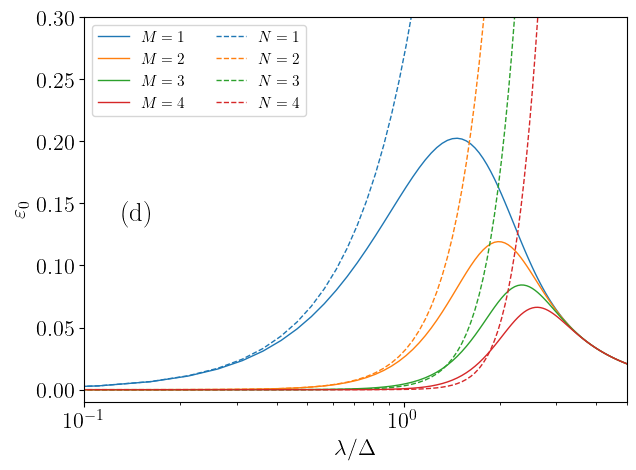

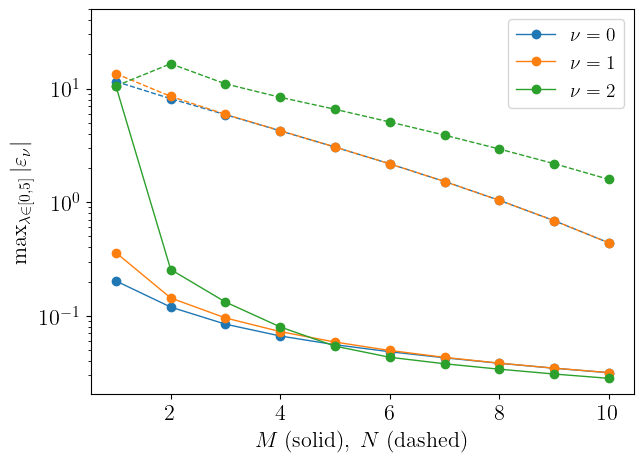

In [11]:
fig, ax = plt.subplots(1,1,figsize=(7,5))
cmap = plt.get_cmap("tab10")

level_num = 1
H_list = [H_EFF_X_1,H_EFF_X_2,H_EFF_X_3,H_EFF_X_4,H_RC_M(1),H_RC_M(2),H_RC_M(3),H_RC_M(4)]
labels = np.array([r"$M = {}$".format(1),
                   r"$M = {}$".format(2),
                   r"$M = {}$".format(3),
                   r"$M = {}$".format(4),
                   r"$N = {}$".format(1),
                   r"$N = {}$".format(2),
                   r"$N = {}$".format(3),
                   r"$N = {}$".format(4)])
for i,H in enumerate(H_list):
    spectra = np.zeros([np.shape(lam_range)[0],level_num])
    for iilam,lam in enumerate(lam_range):
        spectra[iilam,:] = np.real(H(lam).eigenenergies())[:level_num]

    for level in range(level_num):

        err = (spectra[:,level]-spectrum_exact[:,level])
        #/np.abs(spectra[:,level]+spectrum_exact[:,level])

        if i > 3:
            linestyle='dashed'
        else:
            linestyle='solid'

        colors = [cmap(0),cmap(1),cmap(2),cmap(3),cmap(0),cmap(1),cmap(2),cmap(3)]

        ax.plot(lam_range,err,
                label=labels[i],
                linestyle=linestyle,
                linewidth=1,
                color=colors[i])
        
ax.set_xlabel(r"$\lambda/\Delta$")
ax.set_ylabel(r"$\varepsilon_0$")
ax.set_title(r"$\mathrm{(d)}$",
             y=0.45,x=0.1)
ax.legend(fontsize=11, loc='upper left',ncol=2)
ax.set_ylim([-0.01,0.3])
ax.set_xlim([0.1,5.0])
ax.set_xscale('log')

Ms = [1,2,3,4,5,6,7,8,9,10] # up to 10 for main
LVLs = [0,1,2]
plt.savefig('Error1.pdf', format='pdf', bbox_inches='tight')


fig, ax2 = plt.subplots(1,1,figsize=(7,5))
cmap = plt.get_cmap("tab10")

points = np.load('data//err_points_CDH.npy')
for iLVL,LVL in enumerate(LVLs):
    ax2.plot(Ms, points[:,iLVL],
            label=r"$\nu={}$".format(LVL),
            linestyle='solid',
            linewidth=1, 
            color=cmap(iLVL),
            marker='o')
    
points = np.load('data//err_points_Rabi.npy')
for iLVL,LVL in enumerate(LVLs):
    ax2.plot(Ms, points[:,iLVL],
            label='',
            linestyle='dashed',
            linewidth=1, 
            color=cmap(iLVL),
            marker='o')

ax2.set_xlabel(r"$M \; (\mathrm{solid}),\; N \; (\mathrm{dashed})$")
ax2.set_ylabel(r"$\max_{\lambda \in [0,5]} |\varepsilon_\nu|$")
ax2.set_yscale('log')
ax2.set_ylim(top=50)
ax2.legend(fontsize=14)
plt.savefig('Error2.pdf', format='pdf', bbox_inches='tight')

## Appendix: magnetization convergence in dofferent cases ##

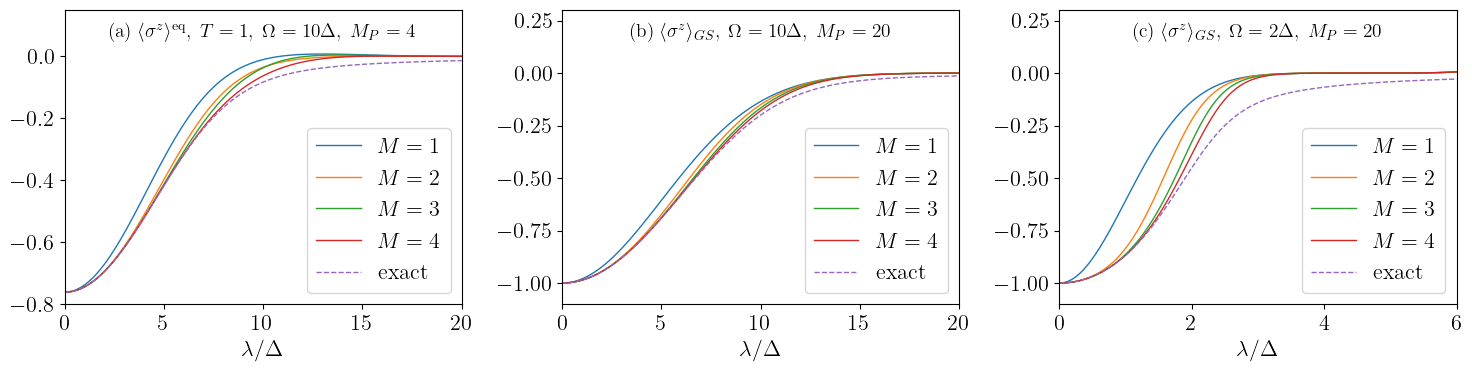

In [12]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
cmap = plt.get_cmap("tab10")

N = 50
H_list = np.array([H_EFF_X_1,H_EFF_X_2,H_EFF_X_3,H_EFF_X_4,H_RC_M(50)])
labels = np.array([r"$M = {}$".format(1),
                   r"$M = {}$".format(2),
                   r"$M = {}$".format(3),
                   r"$M = {}$".format(4),
                   r"$\mathrm{exact}$"])
titles = np.array([r"$\mathrm{(a)} \; \langle \sigma^z \rangle^{\mathrm{eq}}, \; T=1, \; \Omega=10\Delta, \; M_{P}=4$",
                   r"$\mathrm{(b)} \; \langle \sigma^z \rangle_{GS}, \; \Omega=10\Delta, \; M_{P}=20$",
                   r"$\mathrm{(c)} \; \langle \sigma^z \rangle_{GS}, \; \Omega=2\Delta, \; M_{P}=20$"])
obs = sigmaz()

for j in range(3):
    for i,H in enumerate(H_list):

        if j == 0:
            Om = 10
            lam_range = np.linspace(0,20,100)
        if j == 1:
            Om = 10
            lam_range = np.linspace(0,20,100)
        if j == 2:
            Om = 2
            lam_range = np.linspace(0,6,100)    
        ax = axes[j]
        observable = np.zeros(np.shape(lam_range))

        for iilam,lam in enumerate(lam_range):

            if j == 0:
                beta = 1.0
                rho_eq = (-beta*H(lam)).expm() / ( (-beta*H(lam)).expm() ).tr()
            else:
                rho_eq = (H(lam).groundstate()[1]) * (H(lam).groundstate()[1]).dag()
            
            dim = int((np.shape(H(lam))[0]/2))

            if dim == N:
                observable[iilam] = np.real( ( tensor(qeye(dim),obs) * rho_eq ).tr() )    
            else:
                
                M_UP = (j==0)*4 + (j!=0)*20
                # in terms of multiplicities of M:3 bad, 4 good, 5 as good as 4
                # in absotule values of the factor: around 16 off resonance and 24 on at resonance
                UP = build_UP(sigmax().full(),lam/Om,M_UP)
                if M_UP > 1:
                    obs_P = UP @ tensor(qeye(M_UP),obs) @ UP.dag()
                elif M_UP == 1:
                    obs_P = UP @ obs @ UP.dag()
                obs_P = Qobj(obs_P.full()[:2*dim,:2*dim],dims=rho_eq.dims)
                observable[iilam] = np.real( ( obs_P * rho_eq ).tr() )

        if i == 4:
            linestyle='dashed'
        else:
            linestyle='solid'
        ax.plot(lam_range, observable, linestyle=linestyle, linewidth=1, label= labels[i], color=cmap(i))
        ax.set_xlabel(r"$\lambda/\Delta$")
        ax.set_xlim([[0,20],[0,20],[0,6]][j])
        ax.set_ylim([[-0.8,0.15],[-1.1,0.3],[-1.1,0.3]][j])
        ax.legend()
        ax.set_title(titles[j],y=0.88, fontsize=14)

plt.tight_layout()

## Convergence with M_UP ##

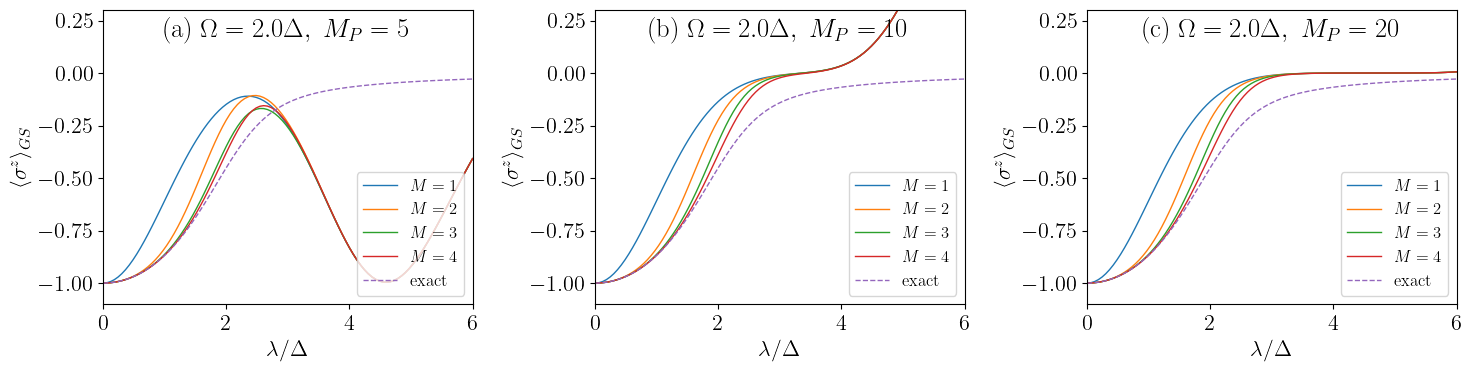

In [13]:
for iOm,Om in enumerate([2.0,]):

    fig, axes = plt.subplots(1,3,figsize=(15,4))
    cmap = plt.get_cmap("tab10")

    N = 50
    MUPS = [5,10,20]
    H_list = np.array([H_EFF_X_1,H_EFF_X_2,H_EFF_X_3,H_EFF_X_4,H_RC_M(50)])
    #H_list = np.array([H_EFF_M(1),H_EFF_M(2),H_EFF_M(3),H_EFF_M(4),H_RC_M(20)])
    labels = np.array([r"$M = {}$".format(1),
                    r"$M = {}$".format(2),
                    r"$M = {}$".format(3),
                    r"$M = {}$".format(4),
                    r"$\mathrm{exact}$"])
    titles = np.array([
        rf"$\mathrm{{(a)}}\; \Omega = {Om} \Delta,\; M_{{P}} = {MUPS[0]}$",
        rf"$\mathrm{{(b)}}\; \Omega = {Om} \Delta,\; M_{{P}} = {MUPS[1]}$",
        rf"$\mathrm{{(c)}}\; \Omega = {Om} \Delta,\; M_{{P}} = {MUPS[2]}$"
    ])
    obs = sigmaz()

    sig_x = np.array([[0,1],[1,0]])
    def a(M):
        A = np.zeros((M, M))
        for i in range(M - 1):
            A[i, i + 1] = np.sqrt(i + 1)
        return A
    def adag(M):
        return a(M).conj().T

    for j in range(3):
        for i,H in enumerate(H_list):

            lam_range = np.linspace(0,[6,8,10][iOm],100)
            ax = axes[j]
            observable = np.zeros(np.shape(lam_range))

            for iilam,lam in enumerate(lam_range):

                rho_eq = (H(lam).groundstate()[1]) * (H(lam).groundstate()[1]).dag()
                dim = int((np.shape(H(lam))[0]/2))

                if i != 4:
                    M_UP = MUPS[j]
                    # in terms of multiplicities of M:3 bad, 4 good, 5 as good as 4
                    # in absotule values of the factor: around 16 off resonance and 24 on at resonance
                    UP = build_UP(sigmax().full(),lam/Om,M_UP)
                    obs_P = UP * tensor(qeye(M_UP),obs) * UP.dag()

                    obs_P = Qobj(obs_P.full()[:2*dim,:2*dim],dims=rho_eq.dims)
                else:
                    obs_P = tensor(qeye(N),obs)

                observable[iilam] = np.real( ( obs_P * rho_eq ).tr() )

            if i == 4:
                linestyle='dashed'
            else:
                linestyle='solid'
            ax.plot(lam_range, observable, linestyle=linestyle, linewidth=1, label=labels[i], color=cmap(i))
            ax.set_xlabel(r"$\lambda/\Delta$")
            ax.set_ylabel(r"$\langle \sigma^z \rangle_{GS}$")
            ax.set_xlim([0,lam_range[-1]])
            ax.set_ylim([-1.1,0.3])
            ax.legend(fontsize=12, loc='lower right')
            ax.set_title(titles[j],y=0.88)

    plt.tight_layout()

## cavity state ##

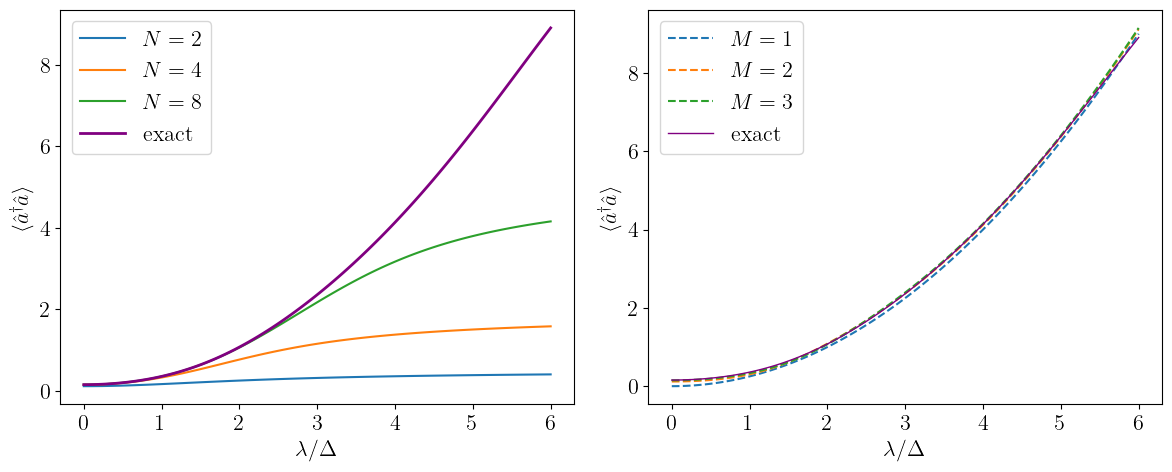

In [37]:
# Compare thermal photon number for different exact-boson sizes (N) and effective sizes (M)
beta = 1.0
Om = 2
# lists to compare
N_list = [2, 4, 8]
M_list = [1, 2, 3]
M_UP = 60  # large boson space for UP transform

# prepare figure with two subplots: left for varying N (exact), right for varying M (effective)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axN, axM = axes

# compute reference exact result for N=20 and plot it on both subplots (purple)
N_ref = 20
a_ref = destroy(N_ref)
num_ref = a_ref.dag() * a_ref
obs_ref_n = np.zeros(np.shape(lam_range))
H_ref_factory = H_RC_M(N_ref)
for i, lam in enumerate(lam_range):
    H_ref = H_ref_factory(lam)
    rho_ref = (-beta * H_ref).expm()
    rho_ref = rho_ref / rho_ref.tr()
    rho_b_ref = rho_ref.ptrace(0)
    obs_ref_n[i] = np.real((num_ref * rho_b_ref).tr())

# exact model: vary N (full Rabi Hamiltonian H_RC_M(N))
for N in N_list:
    a_ex = destroy(N)
    num_ex = a_ex.dag() * a_ex
    obs_ex_n = np.zeros(np.shape(lam_range))
    H_exact_factory = H_RC_M(N)
    for i, lam in enumerate(lam_range):
        H_ex = H_exact_factory(lam)
        rho_ex = (-beta * H_ex).expm()
        rho_ex = rho_ex / rho_ex.tr()
        rho_b = rho_ex.ptrace(0)
        obs_ex_n[i] = np.real((num_ex * rho_b).tr())
    axN.plot(lam_range, obs_ex_n, label=rf"$N={N}$")
# overlay reference N=20 exact result
axN.plot(lam_range, obs_ref_n, color='purple', linewidth=2, label=r"$\mathrm{exact}$")

axN.set_xlabel(r'$\lambda/\Delta$')
axN.set_ylabel(r'$\langle \hat{a}^\dagger \hat{a} \rangle$')
axN.legend()

# effective/CDH model: vary M (input to H_EFF_M)
for M in M_list:
    obs_eff_n = np.zeros(np.shape(lam_range))
    H_eff_factory = H_EFF_M(M)
    for i, lam in enumerate(lam_range):
        H_eff = H_eff_factory(lam)
        rho_eff = (-beta * H_eff).expm()
        rho_eff = rho_eff / rho_eff.tr()
        # transform bosonic number with UP built in large boson space, then slice to eff dims
        UP = build_UP(sigmax().full(), lam/Om, M_UP)
        a_up = destroy(M_UP)
        num_up = a_up.dag() * a_up
        num_t = UP * tensor(num_up, qeye(2)) * UP.dag()
        dim_eff = H_eff.shape[0]
        num_p = Qobj(num_t.full()[:dim_eff, :dim_eff], dims=rho_eff.dims)
        obs_eff_n[i] = np.real((num_p * rho_eff).tr())
    axM.plot(lam_range, obs_eff_n, linestyle='--', label=rf"$M={M}$")
# overlay same reference N=20 exact result on effective plot (purple)
axM.plot(lam_range, obs_ref_n, color='purple', linewidth=1, label=r"$\mathrm{exact}$")

axM.set_xlabel(r'$\lambda/\Delta$')
axM.set_ylabel(r'$\langle \hat{a}^\dagger \hat{a} \rangle$')
axM.legend()

plt.tight_layout()